In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First let's see what files are available
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yeanzc/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx


In [2]:
df = pd.read_excel('/kaggle/input/datasets/yeanzc/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn distribution:")
print(df['Churn Label'].value_counts())
df.head()

Shape: (7043, 33)

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Churn distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# Step 2: Drop irrelevant and leakage columns
df = df.drop(columns=[
    'CustomerID', 'Count', 'Country', 'State', 'City', 
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Score', 'Churn Value', 'Churn Reason'
])

print("Shape after dropping:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape after dropping: (7043, 21)

Missing values:
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

Data types:
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperl

In [4]:
# Fix Total Charges - convert to numeric, invalid values become NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Check how many NaN values appeared
print("NaN in Total Charges:", df['Total Charges'].isnull().sum())

# Drop those rows - there won't be many
df = df.dropna(subset=['Total Charges'])

print("Shape after fix:", df.shape)

NaN in Total Charges: 11
Shape after fix: (7032, 21)


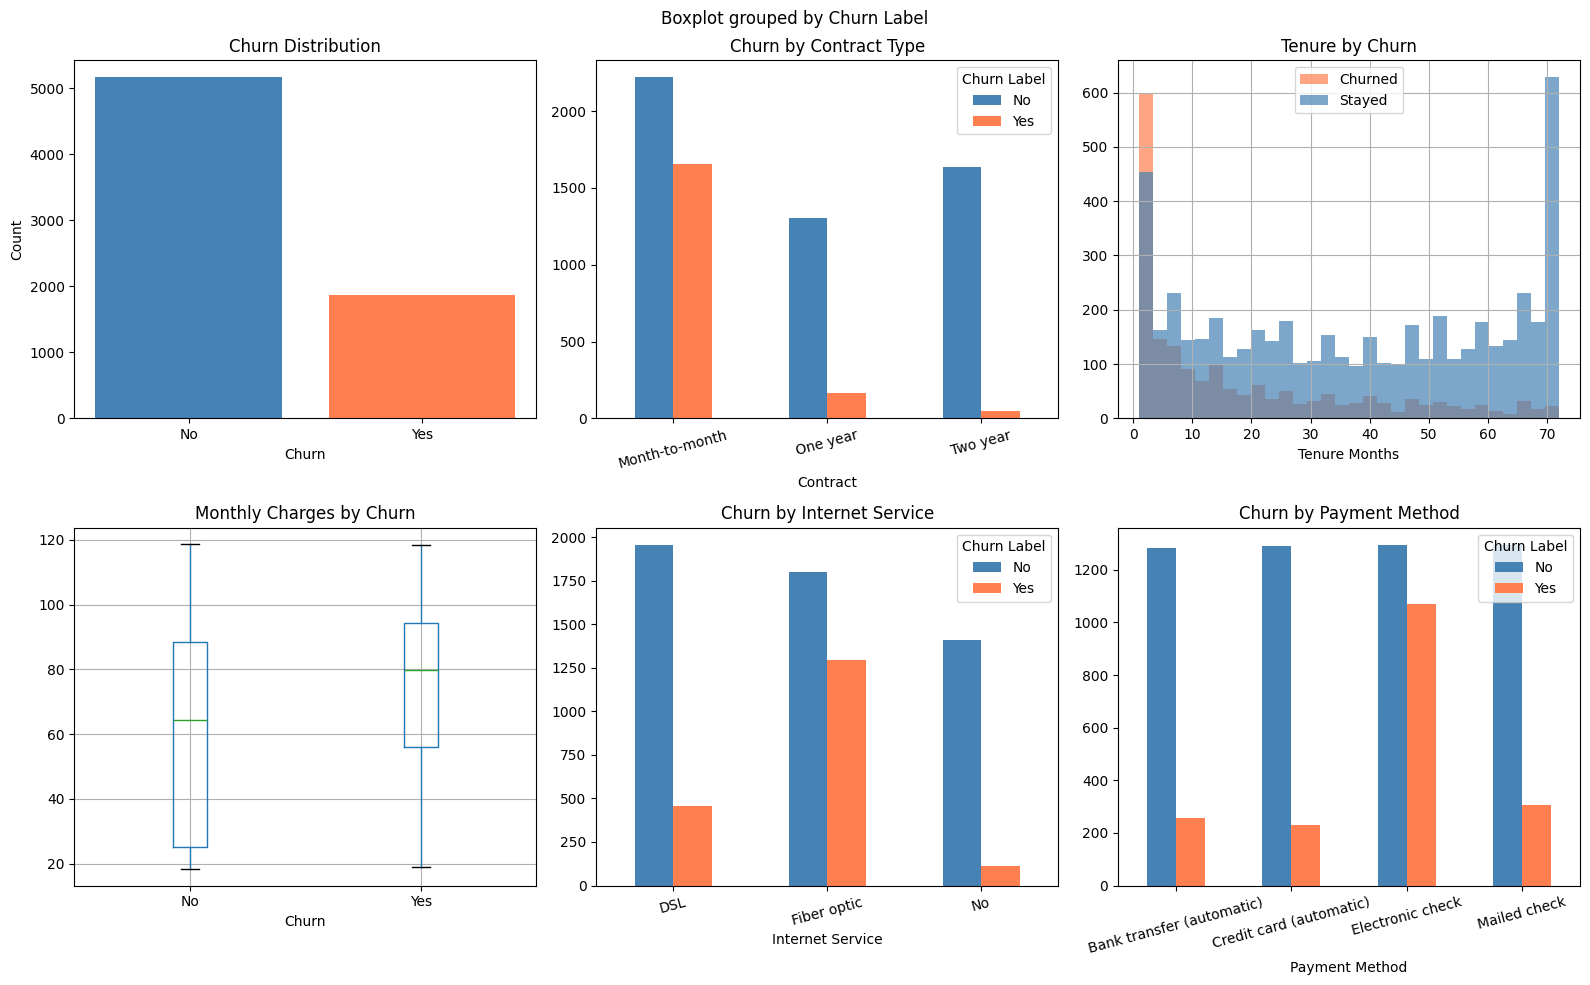

In [5]:
# Step 3: EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telecom Customer Churn - EDA', fontsize=16, fontweight='bold')

# Chart 1: Churn Distribution
churn_counts = df['Churn Label'].value_counts()
axes[0,0].bar(churn_counts.index, churn_counts.values, color=['steelblue','coral'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('Churn')
axes[0,0].set_ylabel('Count')

# Chart 2: Churn by Contract Type
contract_churn = df.groupby(['Contract','Churn Label']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0,1], color=['steelblue','coral'])
axes[0,1].set_title('Churn by Contract Type')
axes[0,1].set_xlabel('Contract')
axes[0,1].tick_params(axis='x', rotation=15)

# Chart 3: Tenure Distribution by Churn
df[df['Churn Label']=='Yes']['Tenure Months'].hist(ax=axes[0,2], bins=30, color='coral', alpha=0.7, label='Churned')
df[df['Churn Label']=='No']['Tenure Months'].hist(ax=axes[0,2], bins=30, color='steelblue', alpha=0.7, label='Stayed')
axes[0,2].set_title('Tenure by Churn')
axes[0,2].set_xlabel('Tenure Months')
axes[0,2].legend()

# Chart 4: Monthly Charges by Churn
df.boxplot(column='Monthly Charges', by='Churn Label', ax=axes[1,0])
axes[1,0].set_title('Monthly Charges by Churn')
axes[1,0].set_xlabel('Churn')

# Chart 5: Churn by Internet Service
internet_churn = df.groupby(['Internet Service','Churn Label']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[1,1], color=['steelblue','coral'])
axes[1,1].set_title('Churn by Internet Service')
axes[1,1].set_xlabel('Internet Service')
axes[1,1].tick_params(axis='x', rotation=15)

# Chart 6: Churn by Payment Method
payment_churn = df.groupby(['Payment Method','Churn Label']).size().unstack()
payment_churn.plot(kind='bar', ax=axes[1,2], color=['steelblue','coral'])
axes[1,2].set_title('Churn by Payment Method')
axes[1,2].set_xlabel('Payment Method')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [6]:
# Step 4: Feature Engineering

# Convert target variable to binary
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# One-hot encode all categorical columns
df_model = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_model.drop(columns=['Churn Label'])
y = df_model['Churn Label']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (7032, 31)
Target distribution:
Churn Label
0    5163
1    1869
Name: count, dtype: int64

Feature columns:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [7]:
# Step 5: Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split first, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 4151, 1: 1474}
After SMOTE:  {0: 4151, 1: 4151}


In [8]:
# Step 6: Build & Compare Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  AUC-ROC:   {auc:.3f}")
    return model

lr  = evaluate_model("Logistic Regression",    LogisticRegression(max_iter=1000, random_state=42),         X_train_sm, X_test, y_train_sm, y_test)
rf  = evaluate_model("Random Forest",          RandomForestClassifier(n_estimators=100, random_state=42),  X_train_sm, X_test, y_train_sm, y_test)
gb  = evaluate_model("Gradient Boosting",      GradientBoostingClassifier(n_estimators=100, random_state=42), X_train_sm, X_test, y_train_sm, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
  Accuracy:  0.783
  AUC-ROC:   0.831

Random Forest
  Accuracy:  0.792
  AUC-ROC:   0.842

Gradient Boosting
  Accuracy:  0.795
  AUC-ROC:   0.852


In [9]:
# Step 7: Tune Gradient Boosting with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

print("Starting GridSearchCV - takes 2-3 minutes...")

gb_tuned = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_tuned.fit(X_train_sm, y_train_sm)

print("\nBest settings:", gb_tuned.best_params_)

y_pred = gb_tuned.best_estimator_.predict(X_test)
y_prob = gb_tuned.best_estimator_.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\nTuned Gradient Boosting")
print(f"  Accuracy:  {acc:.3f}")
print(f"  AUC-ROC:   {auc:.3f}")
print(f"\nImprovement in AUC-ROC: {auc - 0.852:.3f}")

Starting GridSearchCV - takes 2-3 minutes...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best settings: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Tuned Gradient Boosting
  Accuracy:  0.805
  AUC-ROC:   0.849

Improvement in AUC-ROC: -0.003


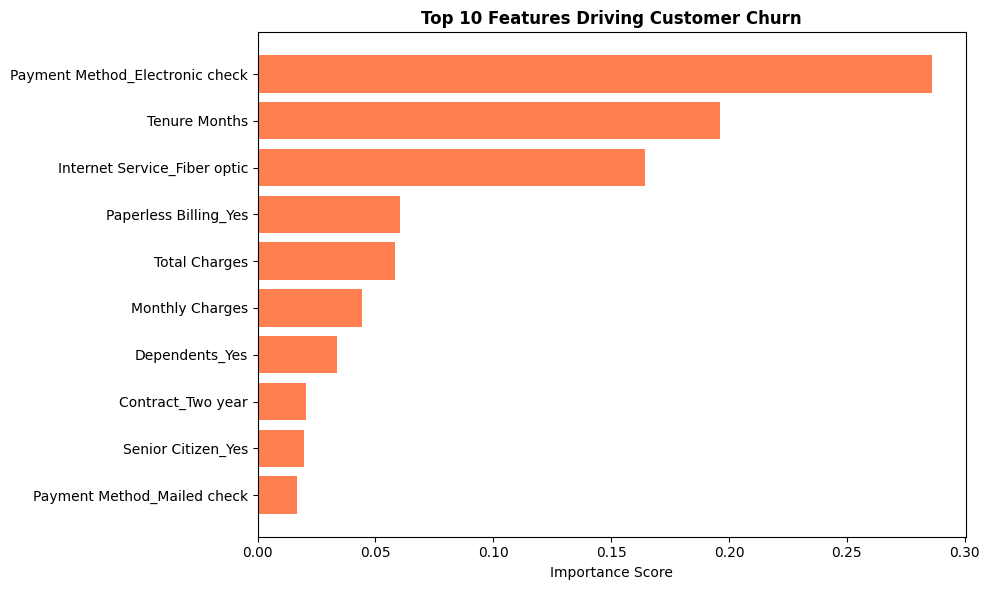


Top 5 churn drivers:
  Payment Method_Electronic check     0.286
  Tenure Months                       0.196
  Internet Service_Fiber optic        0.164
  Paperless Billing_Yes               0.061
  Total Charges                       0.058

Final Model Summary:
  Model:     Gradient Boosting
  Accuracy:  79.5%
  AUC-ROC:   0.852
  Test Set:  1,407 customers


In [10]:
# Step 8: Feature Importance + Business Summary
best_model = gb

importances = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], 
         importance_df['Importance'][::-1], 
         color='coral')
plt.title('Top 10 Features Driving Customer Churn', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
for _, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:.3f}")

print(f"\nFinal Model Summary:")
print(f"  Model:     Gradient Boosting")
print(f"  Accuracy:  79.5%")
print(f"  AUC-ROC:   0.852")
print(f"  Test Set:  {len(y_test):,} customers")